# Jupyter notebook_Carlos
Aplicação Prática de Python na Ciência dos Dados - Parte 2

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [12]:
df = pd.read_excel(r'C:\Users\comut\Downloads\default_of_credit_card_clients__courseware_version_1_21_19.xls')

In [13]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,798fc410-45c1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,8a8c8f3b-8eb4,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,85698822-43f5,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,0737c11b-be42,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,3b7f77cc-dbc0,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [14]:
bill_feats = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3',
              'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
pay_feats = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3',
             'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
print(bill_feats)
print(pay_feats)

['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']


In [15]:
df[bill_feats].describe()

,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6
count,30000.000000,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000
mean,50646.744233,48624.349167,4.649736e+04,42791.362167,39884.398167,38480.350933
std,73376.695080,70893.963498,6.910251e+04,64090.316188,60606.644833,59406.836932
min,-165580.000000,-69777.000000,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000
25%,3234.000000,2682.000000,2.403000e+03,2034.000000,1534.000000,1080.000000
50%,21644.500000,20597.000000,1.975250e+04,18759.500000,17835.500000,16643.000000
75%,66148.500000,62999.750000,5.952675e+04,53572.250000,49804.000000,48863.500000
max,964511.000000,983931.000000,1.664089e+06,891586.000000,927171.000000,961664.000000


Os valores mínimos negativos indicam créditos/estornos na fatura. Os valores máximos são bem altos comparados à média, sugerindo distribuição assimétrica com outliers. O desvio padrão alto confirma grande dispersão. Faz sentido para dados de cartão de crédito.

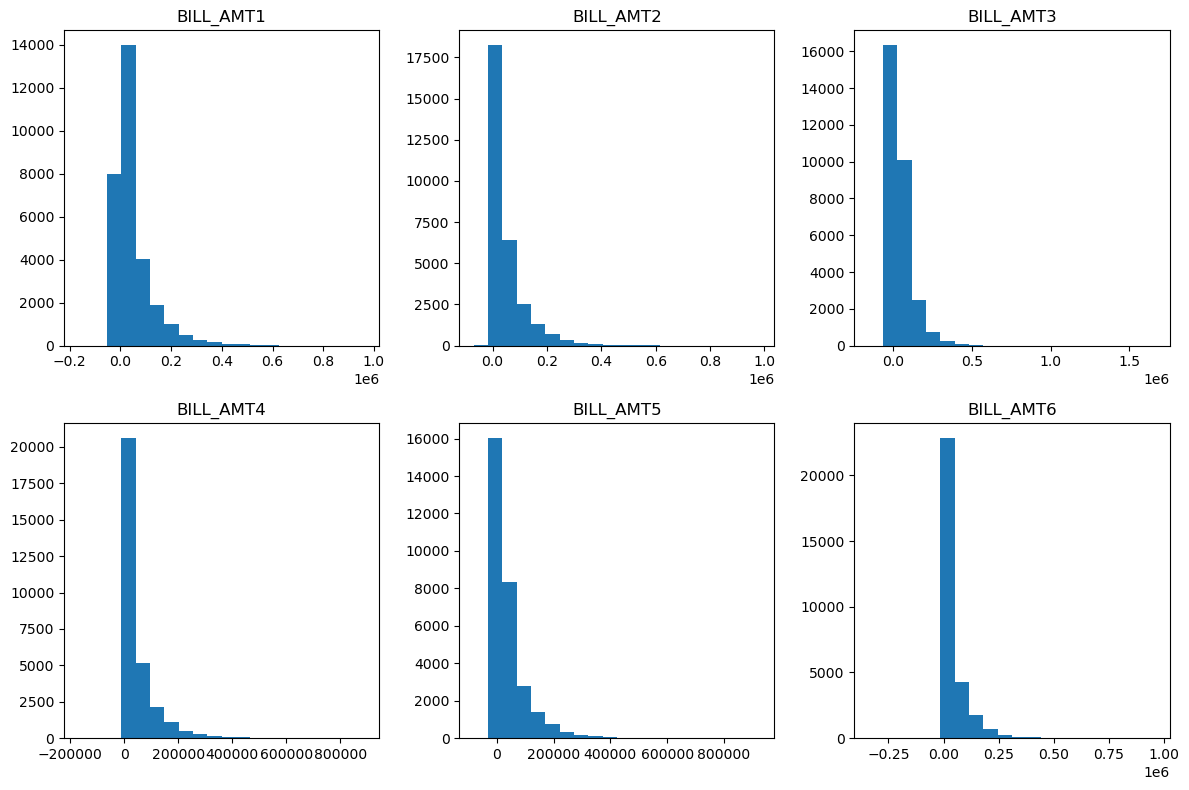

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for i, col in enumerate(bill_feats):
    row = i // 3
    col_idx = i % 3
    axes[row][col_idx].hist(df[col], bins=20)
    axes[row][col_idx].set_title(col)

plt.tight_layout()
plt.show()

In [17]:
df[pay_feats].describe()

,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
count,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000,30000.000000
mean,5613.321500,5.855410e+03,5174.387967,4776.089733,4754.749200,5164.223267
std,16539.094312,2.299256e+04,17565.538305,15532.893047,15239.070708,17712.664703
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,836.000000,7.217500e+02,371.000000,223.000000,170.750000,9.000000
50%,2084.500000,2.000000e+03,1776.000000,1500.000000,1500.000000,1500.000000
75%,5000.000000,5.000000e+03,4500.000000,4000.000000,4000.000000,4000.000000
max,873552.000000,1.684259e+06,896040.000000,621000.000000,426529.000000,528666.000000


Os valores mínimos são 0 (sem pagamento). A média é bem menor que os valores da fatura, indicando que muitos clientes pagam parcialmente. A grande maioria paga pouco ou nada, o que faz sentido dado o contexto de inadimplência.

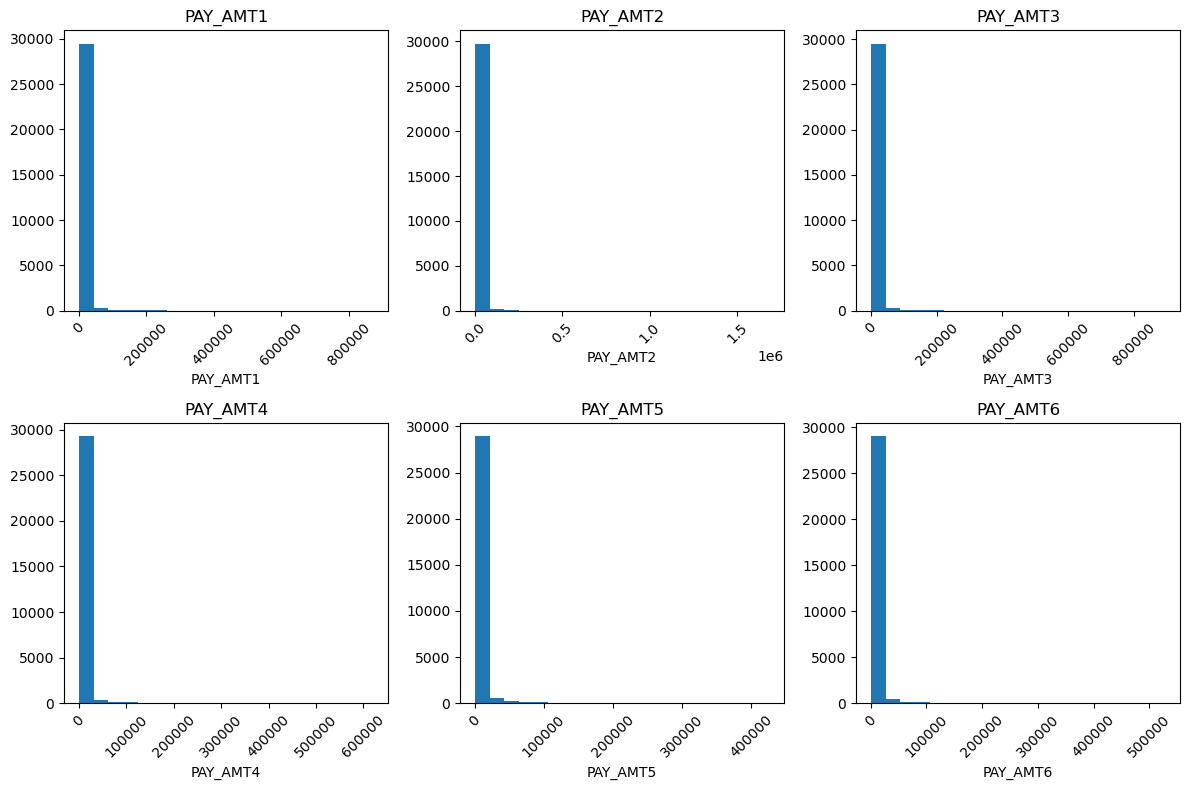

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for i, col in enumerate(pay_feats):
    row = i // 3
    col_idx = i % 3
    axes[row][col_idx].hist(df[col], bins=20)
    axes[row][col_idx].set_title(col)
    axes[row][col_idx].set_xlabel(col, rotation=0)
    plt.sca(axes[row][col_idx])
    plt.xticks(rotation=45)  # xrot=45

plt.tight_layout()
plt.show()

In [19]:
zero_pay_mask = df[pay_feats] == 0

In [20]:
# Criar máscara booleana para pagamentos iguais a zero
zero_pay_mask = df[pay_feats] == 0

# Contar por coluna
print(zero_pay_mask.sum())

# Total geral
print('\nTotal de zeros:', zero_pay_mask.sum().sum())

# Percentual
print('\nPercentual de zeros por coluna:')
print((zero_pay_mask.sum() / len(df) * 100).round(2))

PAY_AMT1    5504
PAY_AMT2    5663
PAY_AMT3    6223
PAY_AMT4    6660
PAY_AMT5    6955
PAY_AMT6    7416
dtype: int64

Total de zeros: 38421

Percentual de zeros por coluna:
PAY_AMT1    18.35
PAY_AMT2    18.88
PAY_AMT3    20.74
PAY_AMT4    22.20
PAY_AMT5    23.18
PAY_AMT6    24.72
dtype: float64


Faz sentido? Sim, Os histogramas anteriores mostravam uma barra enorme no zero, isso confirma que grande parte dos clientes não fez pagamento em determinado mês.

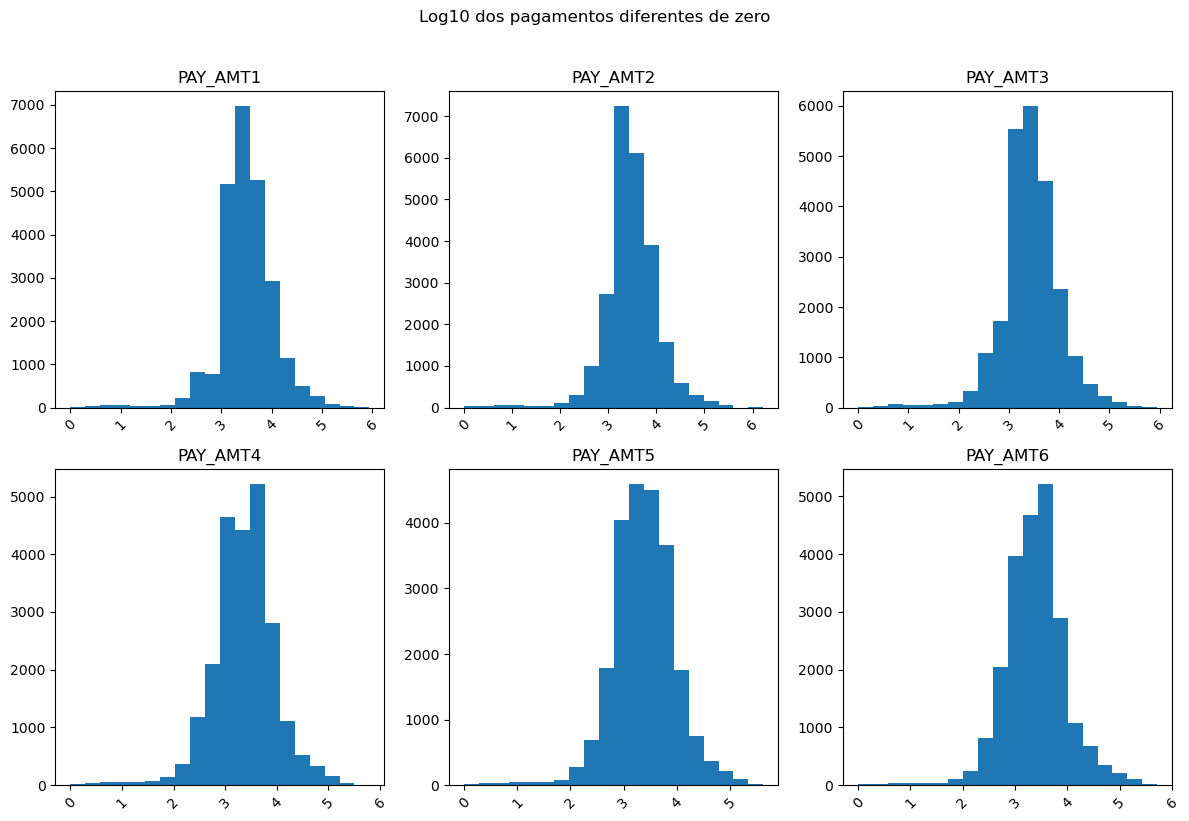

In [21]:
# Usar a máscara inversa para filtrar apenas pagamentos > 0
nonzero_pay = df[pay_feats][~zero_pay_mask]

# Aplicar log10 com .apply() e np.log10
log_pay = nonzero_pay.apply(np.log10)

# Plotar histogramas das transformações logarítmicas
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for i, col in enumerate(pay_feats):
    row = i // 3
    col_idx = i % 3
    axes[row][col_idx].hist(log_pay[col].dropna(), bins=20)
    axes[row][col_idx].set_title(col)
    plt.sca(axes[row][col_idx])
    plt.xticks(rotation=45)

plt.suptitle('Log10 dos pagamentos diferentes de zero', y=1.02)
plt.tight_layout()
plt.show()

Distribuições muito mais próximas da normal, como as mostradas na imagem da atividade. A transformação logarítmica comprime os valores extremos e revela melhor a forma da distribuição.